# ⏱️ Model 03 — City Hour AQI Prediction
**AirVintage Production ML Pipeline — Deployment-Ready**

| Input | Source | Free? |
|-------|--------|-------|
| `PM2.5`, `PM10` | OpenAQ / CPCB API | ✅ |
| `NO2`, `SO2`, `CO`, `O3` | OpenAQ / CPCB API | ✅ |
| `City` | User / GPS | ✅ |
| `Datetime` | System clock | ✅ |

**Dropped:** `NO`, `NOx`, `NH3`, `Benzene`, `Toluene`, `Xylene`

In [1]:
import sys, os, warnings, json
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('.'))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import optuna, joblib

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from airvintage_ml import (
    aqi_to_bucket, health_advisory,
    add_temporal_features,
    encode_categorical, fillna_production, add_entity_stats,
    compute_metrics, print_metrics_table,
    plot_actual_vs_pred, plot_residuals,
    plot_feature_importance, plot_learning_curve_lgb,
    update_model_registry,
)

DATASET='city_hour_cleaned.csv'; MODEL_KEY='city_hour'
MODELS_DIR='models'; REGISTRY=f'{MODELS_DIR}/model_registry.json'; SEED=42
os.makedirs(MODELS_DIR, exist_ok=True)
optuna.logging.set_verbosity(optuna.logging.WARNING)

CORE_POLLUTANTS = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']
print(f'LightGBM {lgb.__version__} | Inputs: {CORE_POLLUTANTS}')

LightGBM 4.6.0 | Inputs: ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']


In [2]:
df = pd.read_csv(DATASET, parse_dates=['Datetime'], low_memory=True)
print(f'Shape: {df.shape[0]:,} x {df.shape[1]} | Cities: {df["City"].nunique()}')
df.head(3)

Shape: 707,875 x 16 | Cities: 26


,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01 01:00:00,0.0,0.0,1.00,40.01,36.37,0.0,1.00,122.07,0.0,0.0,0.0,0.0,0.0,Unknown
1,Ahmedabad,2015-01-01 02:00:00,0.0,0.0,0.02,27.75,19.73,0.0,0.02,85.90,0.0,0.0,0.0,0.0,0.0,Unknown
2,Ahmedabad,2015-01-01 03:00:00,0.0,0.0,0.08,19.32,11.08,0.0,0.08,52.83,0.0,0.0,0.0,0.0,0.0,Unknown


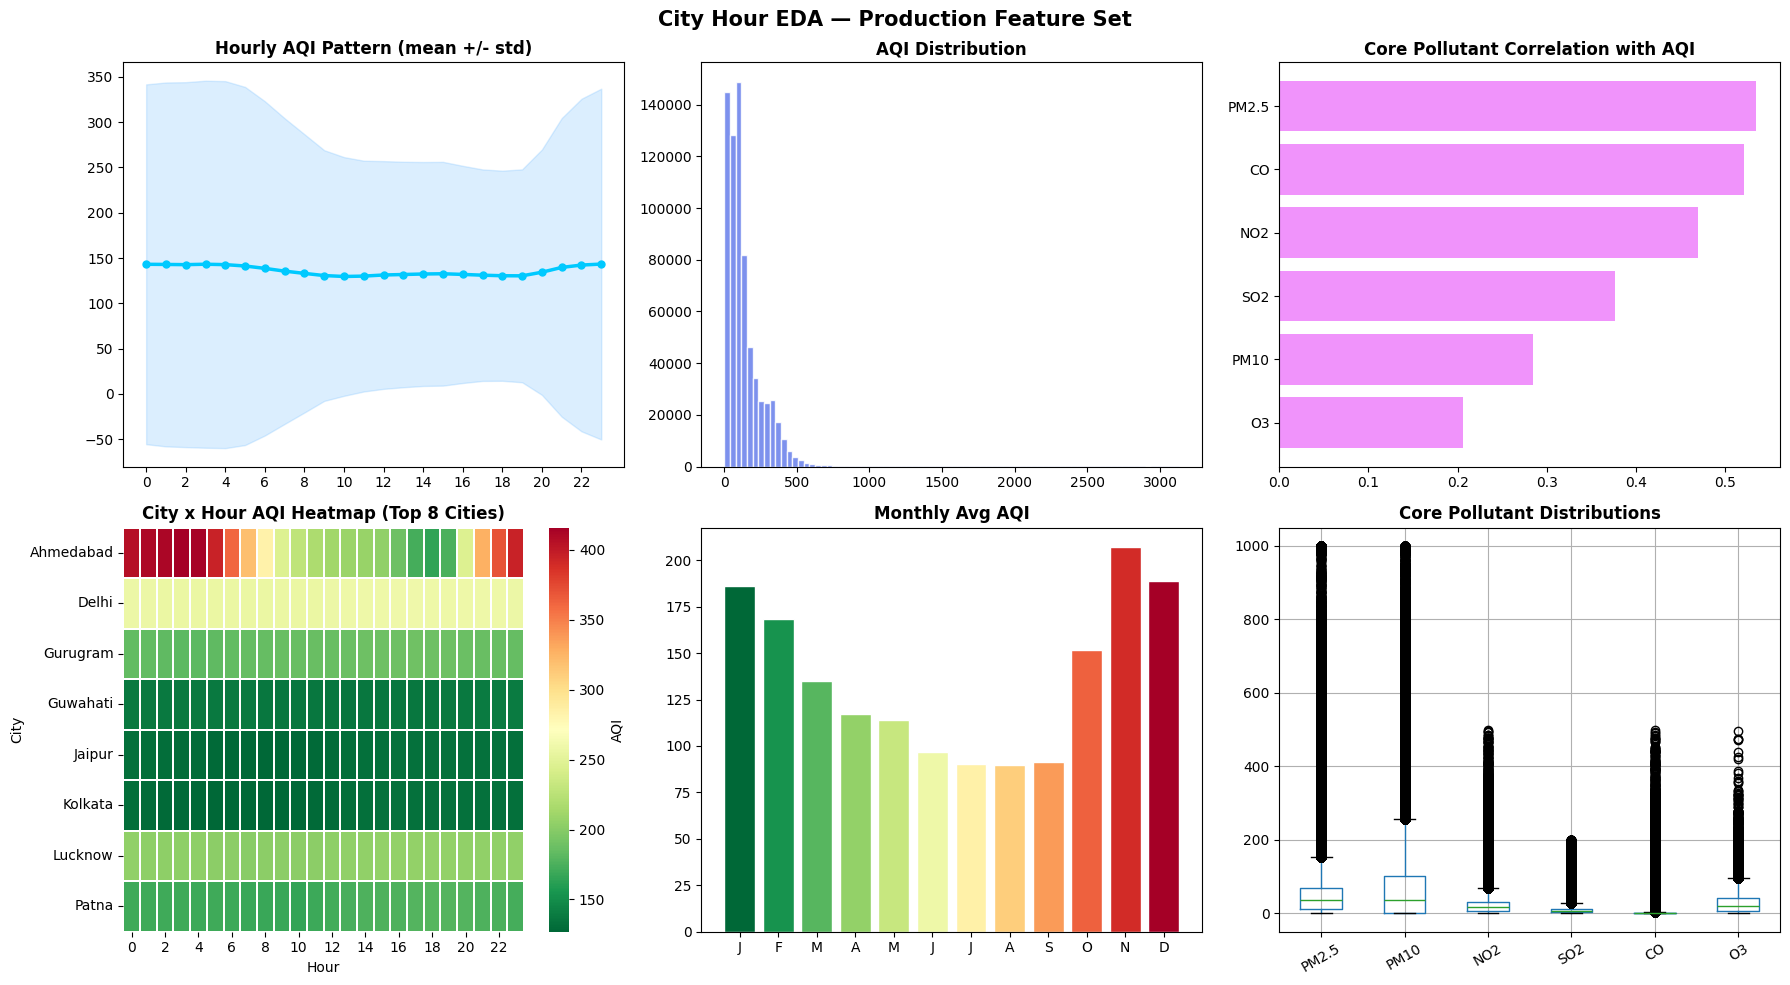

In [3]:
# ── EDA
df_tmp = df.copy()
df_tmp['Hour'] = pd.to_datetime(df_tmp['Datetime']).dt.hour

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

h = df_tmp.groupby('Hour')['AQI'].agg(['mean','std'])
axes[0,0].fill_between(h.index, h['mean']-h['std'], h['mean']+h['std'], alpha=0.2, color='#4facfe')
axes[0,0].plot(h.index, h['mean'], 'o-', lw=2.5, color='#00c9ff', ms=5)
axes[0,0].set_title('Hourly AQI Pattern (mean +/- std)', fontweight='bold')
axes[0,0].set_xticks(range(0,24,2))

axes[0,1].hist(df['AQI'].dropna(), bins=80, color='#667eea', edgecolor='white', alpha=0.85)
axes[0,1].set_title('AQI Distribution', fontweight='bold')

avail = [c for c in CORE_POLLUTANTS if c in df.columns]
corr = df[avail+['AQI']].corr()['AQI'].drop('AQI').abs().sort_values()
axes[0,2].barh(corr.index, corr.values, color='#f093fb')
axes[0,2].set_title('Core Pollutant Correlation with AQI', fontweight='bold')

top8 = df.groupby('City')['AQI'].mean().sort_values(ascending=False).head(8).index
df_tmp2 = df_tmp[df_tmp['City'].isin(top8)]
pivot = df_tmp2.groupby(['City','Hour'])['AQI'].mean().unstack(fill_value=0)
sns.heatmap(pivot, cmap='RdYlGn_r', ax=axes[1,0], linewidths=0.2, cbar_kws={'label':'AQI'})
axes[1,0].set_title('City x Hour AQI Heatmap (Top 8 Cities)', fontweight='bold')

df_tmp['Month_tmp'] = pd.to_datetime(df['Datetime']).dt.month
monthly = df_tmp.groupby('Month_tmp')['AQI'].mean()
axes[1,1].bar(range(1,13), monthly.values, color=plt.cm.RdYlGn_r(np.linspace(0,1,12)), edgecolor='white')
axes[1,1].set_xticks(range(1,13))
axes[1,1].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
axes[1,1].set_title('Monthly Avg AQI', fontweight='bold')

df[[c for c in CORE_POLLUTANTS if c in df.columns]].boxplot(ax=axes[1,2])
axes[1,2].set_title('Core Pollutant Distributions', fontweight='bold')
axes[1,2].tick_params(axis='x', rotation=30)

fig.suptitle('City Hour EDA — Production Feature Set', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{MODELS_DIR}/eda_03_city_hour.png', dpi=120, bbox_inches='tight')
plt.show()

In [4]:
# ── Feature Engineering — Production Only
df_feat = df.copy()
df_feat = add_temporal_features(df_feat, 'Datetime')

df_feat['PM_ratio'] = df_feat['PM2.5'] / (df_feat['PM10'] + 1e-6)
df_feat['Total_PM'] = df_feat['PM2.5'] + df_feat['PM10']
df_feat['NO2_SO2']  = df_feat['NO2']   + df_feat['SO2']
df_feat['CO_O3']    = df_feat['CO']    * df_feat['O3']

df_feat, le_city   = encode_categorical(df_feat, 'City')
df_feat, city_stats = add_entity_stats(df_feat, 'City_encoded', 'AQI')

DROP = ['City','Datetime','AQI','AQI_Bucket',
        'NO','NOx','NH3','Benzene','Toluene','Xylene']
FEATURE_COLS = [c for c in df_feat.columns if c not in DROP]

df_clean = df_feat.dropna(subset=['AQI']).copy()
df_clean = fillna_production(df_clean)
X, y = df_clean[FEATURE_COLS], df_clean['AQI']
print(f'Production features ({len(FEATURE_COLS)}): {FEATURE_COLS}')

Production features (37): ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3', 'Year', 'Month', 'DayOfYear', 'Quarter', 'DayOfWeek', 'WeekOfYear', 'IsWeekend', 'IsMonsoon', 'IsWinter', 'Hour', 'IsRushHour', 'IsNight', 'IsMidnight', 'Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos', 'DOY_sin', 'DOY_cos', 'DayOfWeek_sin', 'DayOfWeek_cos', 'PM_ratio', 'Total_PM', 'NO2_SO2', 'CO_O3', 'City_encoded', 'City_encoded_AQI_mean', 'City_encoded_AQI_std', 'City_encoded_AQI_median', 'City_encoded_AQI_q25', 'City_encoded_AQI_q75']


In [5]:
X_train,X_tmp,y_train,y_tmp = train_test_split(X,y,test_size=0.30,random_state=SEED)
X_val,X_test,y_val,y_test   = train_test_split(X_tmp,y_tmp,test_size=0.50,random_state=SEED)
print(f'Train:{X_train.shape[0]:,} | Val:{X_val.shape[0]:,} | Test:{X_test.shape[0]:,}')

Train:495,512 | Val:106,181 | Test:106,182


In [6]:
# ── Optuna Tuning
def objective(trial):
    p = {
        'n_estimators'     : trial.suggest_int('n_estimators', 500, 2000),
        'learning_rate'    : trial.suggest_float('lr', 0.01, 0.15, log=True),
        'max_depth'        : trial.suggest_int('max_depth', 6, 12),
        'num_leaves'       : trial.suggest_int('num_leaves', 63, 255),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('csb', 0.5, 1.0),
        'reg_alpha'        : trial.suggest_float('alpha', 1e-4, 5.0, log=True),
        'reg_lambda'       : trial.suggest_float('lam', 1e-4, 5.0, log=True),
        'random_state':SEED, 'n_jobs':-1, 'verbose':-1
    }
    m = lgb.LGBMRegressor(**p)
    m.fit(X_train,y_train,eval_set=[(X_val,y_val)],
          callbacks=[lgb.early_stopping(40,verbose=False)])
    return float(np.sqrt(np.mean((y_val-m.predict(X_val))**2)))

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30, show_progress_bar=True)
best_params = study.best_params
print(f'Best RMSE: {study.best_value:.4f}')

  0%|          | 0/30 [00:00<?, ?it/s]

Best RMSE: 53.9114


In [ ]:
model = lgb.LGBMRegressor(**best_params, random_state=SEED, n_jobs=-1, verbose=-1)
model.fit(X_train,y_train,eval_set=[(X_val,y_val)],
          callbacks=[lgb.early_stopping(75,verbose=False),lgb.log_evaluation(200)])

# Use the .copy() trick to safely pass n_estimators
cv_params = best_params.copy()
cv_params['n_estimators'] = model.best_iteration_

kr2 = cross_val_score(lgb.LGBMRegressor(**cv_params, verbose=-1),
                       X,y,cv=KFold(5,shuffle=True,random_state=SEED),scoring='r2',n_jobs=-1)
print(f'5-Fold CV R2: {kr2.mean():.4f} +/- {kr2.std():.4f}')


[200]	valid_0's l2: 4202.35
[400]	valid_0's l2: 3785.4
[600]	valid_0's l2: 3538.15
[800]	valid_0's l2: 3370.15
[1000]	valid_0's l2: 3249.27
[1200]	valid_0's l2: 3160.45


TypeError: lightgbm.sklearn.LGBMRegressor() got multiple values for keyword argument 'n_estimators'

In [ ]:
train_m=compute_metrics(y_train,model.predict(X_train))
val_m  =compute_metrics(y_val,  model.predict(X_val))
test_m =compute_metrics(y_test, model.predict(X_test))
print_metrics_table({'Train':train_m,'Val':val_m,'Test':test_m})

plot_learning_curve_lgb(model,'LGB Curve — City Hour',f'{MODELS_DIR}/lc_03_city_hour.png')
plot_actual_vs_pred(y_test,model.predict(X_test),'Actual vs Pred — City Hour',f'{MODELS_DIR}/avp_03_city_hour.png')
plot_residuals(y_test,model.predict(X_test),'Residuals — City Hour',f'{MODELS_DIR}/res_03_city_hour.png')
plot_feature_importance(FEATURE_COLS,model.feature_importances_,'Feature Importance — City Hour',savepath=f'{MODELS_DIR}/fi_03_city_hour.png')

In [ ]:
model.booster_.save_model(f'{MODELS_DIR}/03_city_hour_lgb.txt')
joblib.dump(le_city, f'{MODELS_DIR}/03_city_hour_le_city.pkl')
city_stats.to_csv(f'{MODELS_DIR}/03_city_hour_city_stats.csv', index=False)
with open(f'{MODELS_DIR}/03_city_hour_features.json','w') as f: json.dump(FEATURE_COLS,f,indent=2)
with open(f'{MODELS_DIR}/03_city_hour_input_schema.json','w') as f:
    json.dump({'required_inputs':['city','datetime']+CORE_POLLUTANTS,
               'note':'Datetime includes hour; all pollutants from OpenAQ/CPCB'},f,indent=2)

update_model_registry(REGISTRY,MODEL_KEY,'LightGBM+Optuna',DATASET,test_m,
    model_paths={'model':f'{MODELS_DIR}/03_city_hour_lgb.txt','encoder':f'{MODELS_DIR}/03_city_hour_le_city.pkl',
                 'city_stats':f'{MODELS_DIR}/03_city_hour_city_stats.csv','features':f'{MODELS_DIR}/03_city_hour_features.json'},
    feature_count=len(FEATURE_COLS),notes='Inputs: PM2.5,PM10,NO2,SO2,CO,O3 + city + datetime')
print('Model 03 saved.')

In [ ]:
def predict_city_hour(
    city: str, datetime_str: str,
    pm25: float, pm10: float,
    no2: float, so2: float, co: float, o3: float
) -> dict:
    """
    Predict hourly AQI for a city.
    All inputs from free APIs (OpenAQ/CPCB + system clock).
    """
    row = pd.DataFrame([{'City':city,'Datetime':datetime_str,
                          'PM2.5':pm25,'PM10':pm10,'NO2':no2,'SO2':so2,'CO':co,'O3':o3}])
    row['Datetime'] = pd.to_datetime(row['Datetime'])
    row = add_temporal_features(row,'Datetime')
    row['PM_ratio']=pm25/(pm10+1e-6); row['Total_PM']=pm25+pm10
    row['NO2_SO2']=no2+so2; row['CO_O3']=co*o3

    c_enc = int(le_city.transform([city])[0]) if city in le_city.classes_ else -1
    row['City_encoded'] = c_enc
    sr = city_stats[city_stats['City_encoded']==c_enc]
    for col in [c for c in city_stats.columns if 'AQI' in c]:
        row[col] = float(sr[col].values[0]) if len(sr)>0 else 150.0

    X_in = row[FEATURE_COLS].fillna(0)
    aqi  = float(model.predict(X_in)[0])
    b    = aqi_to_bucket(aqi)
    return {'model':'city_hour','city':city,'datetime':datetime_str,
            'predicted_aqi':round(aqi,2),'aqi_category':b,'health_advisory':health_advisory(b)}

demo = predict_city_hour('Delhi','2025-01-15 08:00:00',
                          pm25=110,pm10=160,no2=55,so2=15,co=1.8,o3=20)
print('Demo:'); [print(f'  {k}: {v}') for k,v in demo.items()]